# Trustworthy Brain Tumor Classification
## Combining Spatial Attention (CBAM) and Uncertainty Estimation


---

### Project Overview
This notebook implements a CNN architecture augmented with:
1. **CBAM (Convolutional Block Attention Module)** for interpretability
2. **Deep Ensembles + MC Dropout + Temperature Scaling** for uncertainty quantification

### Key Improvements in This Version
- Two-stage training for CBAM
- Differential learning rates
- Proper CBAM weight initialization
- Label smoothing for better calibration

## Part 1: Setup and Imports

In [1]:
# --- IMPORTS ---
# Standard libraries and common ML/vision packages used in the notebook.
# - kagglehub: helper to download the dataset (project-specific helper)
# - torch / torchvision: model, training and transforms
# - PIL / numpy / matplotlib: image manipulation and plotting
# - sklearn / scipy / seaborn: metrics and statistical analysis
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from scipy.stats import spearmanr
import seaborn as sns
import os
import shutil
from collections import Counter
import torch.nn.functional as F
import json
import warnings
warnings.filterwarnings('ignore')

# Reproducibility: set seeds for numpy and torch
torch.manual_seed(42)
np.random.seed(42)

# Device selection (supports MPS for Apple Silicon, CUDA, or CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA GPU - {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: CUDA GPU - NVIDIA A100-SXM4-40GB


## Part 2: Data Acquisition and Preparation

In [2]:
# --- DATA ACQUISITION ---
# Download the dataset from Kaggle (uses kagglehub helper).
# Note: this may download a zip and extract to a path returned by the helper.
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print(f"Data downloaded to: {path}")

# Use Path to work with filesystem paths cleanly
dataset_path = Path(path)
print("\nDirectory structure:")
# Print discovered directories so users can confirm where class folders live
for item in dataset_path.rglob("*"):
    if item.is_dir():
        print(f"  Found folder: {item.name}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Data downloaded to: /kaggle/input/brain-tumor-mri-dataset

Directory structure:
  Found folder: Training
  Found folder: Testing
  Found folder: pituitary
  Found folder: notumor
  Found folder: meningioma
  Found folder: glioma
  Found folder: pituitary
  Found folder: notumor
  Found folder: meningioma
  Found folder: glioma


In [3]:
# --- DATA SPLITTING FUNCTION ---
# The dataset should have class subfolders (e.g., glioma, meningioma, pituitary, notumor).
# This function finds the class folder location, performs a stratified train/val/test split,
# and copies images into a new organized folder structure: output_path/{train,val,test}/{class}/*

def create_train_val_test_split(dataset_path, output_path, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """Create stratified train/val/test split from the dataset.

    The function searches common locations under `dataset_path` (Training, Testing, or root),
    collects image paths and labels, and performs stratified splitting using sklearn.
    """
    output_path = Path(output_path)

    possible_data_dirs = [
        dataset_path / "Training",
        dataset_path / "Testing",
        dataset_path,
    ]

    # Find where the class folders are
    data_dir = None
    for possible_dir in possible_data_dirs:
        if possible_dir.exists():
            class_folders = [f for f in possible_dir.iterdir() if f.is_dir()]
            if len(class_folders) > 0:
                data_dir = possible_dir
                break

    if data_dir is None:
        raise ValueError(f"Could not find class folders in {dataset_path}")

    print(f"Found data directory: {data_dir}")

    # Get class names and create output dirs for each split
    class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    print(f"Classes found: {class_names}")

    for split in ['train', 'val', 'test']:
        for class_name in class_names:
            (output_path / split / class_name).mkdir(parents=True, exist_ok=True)

    # Collect all image paths with integer labels
    all_images = []
    all_labels = []

    for class_idx, class_name in enumerate(class_names):
        class_path = data_dir / class_name
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.png"))
        all_images.extend(images)
        all_labels.extend([class_idx] * len(images))

    print(f"\nTotal images found: {len(all_images)}")
    print(f"Class distribution: {Counter([class_names[label] for label in all_labels])}")

    # Stratified split: first split into train vs (val+test) preserving class distribution
    train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
        all_images, all_labels, test_size=(val_ratio + test_ratio),
        stratify=all_labels, random_state=42
    )

    # Split the temporary set into validation and test sets (again stratified)
    val_imgs, test_imgs, val_labels, test_labels = train_test_split(
        temp_imgs, temp_labels, test_size=test_ratio/(val_ratio + test_ratio),
        stratify=temp_labels, random_state=42
    )

    # Copy files to the organized structure (preserves original files)
    def copy_files(image_list, label_list, split_name):
        for img_path, label in tqdm(zip(image_list, label_list),
                                     desc=f"Copying {split_name} files",
                                     total=len(image_list)):
            class_name = class_names[label]
            dest_path = output_path / split_name / class_name / img_path.name
            shutil.copy2(img_path, dest_path)

    copy_files(train_imgs, train_labels, 'train')
    copy_files(val_imgs, val_labels, 'val')
    copy_files(test_imgs, test_labels, 'test')

    # Print split statistics for user awareness
    print(f"\nSplit complete:")
    print(f"  Train: {len(train_imgs)} images")
    print(f"  Val: {len(val_imgs)} images")
    print(f"  Test: {len(test_imgs)} images")

    return output_path, class_names

# Create organized dataset (skip if already present)
organized_data_path = Path("./brain_tumor_organized")
if not organized_data_path.exists():
    organized_data_path, class_names = create_train_val_test_split(dataset_path, organized_data_path)
else:
    class_names = sorted([d.name for d in (organized_data_path / 'train').iterdir() if d.is_dir()])
    print(f"Using existing organized data at {organized_data_path}")

print(f"\nClass mapping:")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")

Found data directory: /kaggle/input/brain-tumor-mri-dataset/Training
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']

Total images found: 5712
Class distribution: Counter({'notumor': 1595, 'pituitary': 1457, 'meningioma': 1339, 'glioma': 1321})


Copying test files: 100%|██████████| 857/857 [00:06<00:00, 138.13it/s]


Split complete:
  Train: 3998 images
  Val: 857 images
  Test: 857 images

Class mapping:
  0: glioma
  1: meningioma
  2: notumor
  3: pituitary


# --- DATASET AND DATALOADER SETUP ---

In [4]:
# --- DATASET CLASS ---
# Simple Dataset wrapper that reads images from folder structure created by create_train_val_test_split.
class BrainTumorDataset(Dataset):
    """Dataset for brain tumor images organized as: root/{class}/*.jpg

    - `data_dir`: path to folder containing class subfolders
    - `transform`: torchvision transforms applied to each image
    """
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.classes = sorted([d.name for d in self.data_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        # Collect all image paths and labels
        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_path = self.data_dir / class_name
            class_images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.png"))
            self.images.extend(class_images)
            self.labels.extend([self.class_to_idx[class_name]] * len(class_images))

        print(f"Loaded {len(self.images)} images from {data_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Load image and apply transforms (return tensor, label)
        img_path = self.images[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')  # Load image as RGB
        if self.transform:
            image = self.transform(image)  # Apply torchvision transforms
        return image, label

    # Utility for training with class imbalance (use as `weight` for CrossEntropyLoss)
    def get_class_weights(self):
        class_counts = Counter(self.labels)
        total = len(self.labels)
        # weight inversely proportional to class frequency
        weights = [total / (len(self.classes) * class_counts[i]) for i in range(len(self.classes))]
        return torch.FloatTensor(weights)

In [5]:
# ImageNet normalization stats (required for pre-trained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Augmentation is key for medical data, but keep it mild so we don't hallucinate tumors.
# Transforms are applied during training to improve generalization. Validation/Test transforms
# should not include random augmentations so results are deterministic.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # Small left/right flips
    transforms.RandomRotation(degrees=10),  # Small rotations to simulate orientation variance
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Intensity/contrast jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation/Test transforms (no augmentation, only normalization)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined:")
print(f"- Train: Resize -> HorizontalFlip -> Rotation(±10°) -> ColorJitter -> Normalize")
print(f"- Val/Test: Resize -> Normalize")

# Create datasets using the organized folder structure
train_dataset = BrainTumorDataset(organized_data_path / 'train', transform=train_transform)
val_dataset = BrainTumorDataset(organized_data_path / 'val', transform=val_test_transform)
test_dataset = BrainTumorDataset(organized_data_path / 'test', transform=val_test_transform)

# Compute class weights for imbalanced dataset handling
class_weights = train_dataset.get_class_weights()
print(f"\nClass weights: {class_weights}")

# Create dataloaders (num_workers=0 to avoid multiprocessing issues in some environments)
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"DataLoaders ready (batch_size={batch_size})")

Transforms defined:
- Train: Resize -> HorizontalFlip -> Rotation(±10°) -> ColorJitter -> Normalize
- Val/Test: Resize -> Normalize
Loaded 3998 images from brain_tumor_organized/train
Loaded 857 images from brain_tumor_organized/val
Loaded 857 images from brain_tumor_organized/test

Class weights: tensor([1.0805, 1.0667, 0.8956, 0.9799])
DataLoaders ready (batch_size=32)


## Part 3: Model Definitions

In [6]:
# --- BASELINE MODEL ---
# Transfer learning model using ResNet50. Need to change the last layer.
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(BaselineCNN, self).__init__()
        # Load pre-trained ResNet-50
        self.resnet = models.resnet50(pretrained=pretrained)

        # Tried freezing the layers but ended up getting better results when fine-tuning the whole thing.
        # Keeping this commented just in case...
        # for param in self.resnet.parameters():
        #     param.requires_grad = False

        # Replace final fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5), # Dropout for regularization
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def enable_dropout_inference(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()

print("Baseline CNN defined.")

Baseline CNN defined.


In [7]:
# --- CBAM ATTENTION MODULE ---
# CBAM is a lightweight attention block combining channel and spatial attention.
# - ChannelAttention: identifies which feature channels are important
# - SpatialAttention: identifies which spatial locations to emphasize

class ChannelAttention(nn.Module):
    """Channel Attention - learns WHAT features to focus on."""
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # Small MLP implemented with 1x1 convolutions for channel mixing
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Apply average and max pooling across spatial dims, pass through shared MLP
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)


class SpatialAttention(nn.Module):
    """Spatial Attention - learns WHERE to focus."""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        # Convolution over concatenated channel-wise avg and max maps
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Compute channel-wise average and max and concatenate for spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(concat))


class CBAM(nn.Module):
    """Convolutional Block Attention Module.

    Stores the last computed attention maps (detached tensors) so callers can
    inspect or visualize the spatial attention after a forward pass.
    """
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)
        self.last_channel_attention = None
        self.last_spatial_attention = None

    def forward(self, x):
        # Channel attention: scale channels
        channel_att = self.channel_attention(x)
        self.last_channel_attention = channel_att.detach()
        x = x * channel_att

        # Spatial attention: scale spatial locations
        spatial_att = self.spatial_attention(x)
        self.last_spatial_attention = spatial_att.detach()
        x = x * spatial_att

        return x

print("CBAM module defined.")

CBAM module defined.


In [8]:
# --- RESNET-50 WITH CBAM ---
# Wraps a pretrained ResNet-50 and inserts CBAM blocks after major layers.
# The model stores intermediate feature maps and spatial attention maps for
# later analysis/visualization (via `get_attention_maps()` / `get_feature_maps()`).

class ResNet50_CBAM(nn.Module):
    """ResNet-50 with CBAM attention after each residual block."""

    def __init__(self, num_classes=4, pretrained=True, reduction=16):
        super(ResNet50_CBAM, self).__init__()

        # Load pretrained ResNet-50 and reuse most layers
        resnet = models.resnet50(pretrained=pretrained)

        # Reuse initial convolution / normalization / activation / pooling
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        # Reuse residual layers
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # Attach CBAM blocks to each major layer output
        self.cbam1 = CBAM(256, reduction)
        self.cbam2 = CBAM(512, reduction)
        self.cbam3 = CBAM(1024, reduction)
        self.cbam4 = CBAM(2048, reduction)

        # Final pooling + classifier
        self.avgpool = resnet.avgpool
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes),
        )

        # Containers to hold attention and feature maps for inspection
        self.attention_maps = {}
        self.feature_maps = {}

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # After each layer, save feature maps and run CBAM
        x = self.layer1(x)
        self.feature_maps['layer1'] = x.detach()
        x = self.cbam1(x)
        self.attention_maps['layer1'] = self.cbam1.last_spatial_attention

        x = self.layer2(x)
        self.feature_maps['layer2'] = x.detach()
        x = self.cbam2(x)
        self.attention_maps['layer2'] = self.cbam2.last_spatial_attention

        x = self.layer3(x)
        self.feature_maps['layer3'] = x.detach()
        x = self.cbam3(x)
        self.attention_maps['layer3'] = self.cbam3.last_spatial_attention

        x = self.layer4(x)
        self.feature_maps['layer4'] = x.detach()
        x = self.cbam4(x)
        self.attention_maps['layer4'] = self.cbam4.last_spatial_attention

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def get_attention_maps(self):
        # Return stored spatial attention maps (call after forward pass)
        return self.attention_maps

    def get_feature_maps(self):
        # Return stored intermediate feature maps
        return self.feature_maps

    def enable_dropout_inference(self):
        # Put Dropout layers into train mode to enable MC Dropout at inference
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()

print("ResNet50_CBAM defined.")

ResNet50_CBAM defined.


In [9]:
# --- CBAM WEIGHT INITIALIZATION  ---
# Initialize CBAM-specific layers to neutralize attention at start of training.
# This helps prevent the attention blocks from perturbing pretrained ResNet features too strongly.

def initialize_cbam_weights(model):
    """Initialize CBAM layers for stable training.

    Key insight: Initialize spatial attention to output ~0.5 (neutral) so CBAM doesn't
    disrupt pretrained features initially.
    """
    for name, module in model.named_modules():
        # Only initialize convolutional modules inside CBAM blocks
        if 'cbam' in name:
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

    # Set spatial attention conv weights small so the sigmoid output is near 0.5 initially
    for cbam in [model.cbam1, model.cbam2, model.cbam3, model.cbam4]:
        nn.init.constant_(cbam.spatial_attention.conv.weight, 0.01)

    print("CBAM weights initialized for stable training")
    return model

print("CBAM initialization function defined.")

CBAM initialization function defined.


In [10]:
# --- LABEL SMOOTHING LOSS ---

class LabelSmoothingLoss(nn.Module):
    """Cross entropy with label smoothing for better calibration."""

    def __init__(self, num_classes, smoothing=0.1, weight=None):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_value = self.smoothing / (self.num_classes - 1)

        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_target = one_hot * confidence + (1 - one_hot) * smooth_value

        log_prob = F.log_softmax(pred, dim=1)

        if self.weight is not None:
            weight_expanded = self.weight[target].unsqueeze(1)
            loss = (-smooth_target * log_prob * weight_expanded).sum(dim=1)
        else:
            loss = (-smooth_target * log_prob).sum(dim=1)

        return loss.mean()

print("Label smoothing loss defined.")

Label smoothing loss defined.


## Part 4: Training Functions

In [11]:
# --- TRAINING FUNCTIONS ---
# train_epoch: runs one epoch of training and returns (avg_loss, accuracy_percent)
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # tqdm provides progress bar during epoch
    pbar = tqdm(dataloader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # accumulate metrics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{100*correct/total:.2f}%"})

    # return average loss and accuracy percentage
    return running_loss / len(dataloader.dataset), 100 * correct / total


# validate_epoch: runs model in eval mode and returns (avg_loss, accuracy_percent, per_class_f1, preds, labels)
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validating")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # keep predictions and labels for later metrics (CPU arrays)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{100*correct/total:.2f}%"})

    f1_scores = f1_score(all_labels, all_preds, average=None)
    # return loss average, accuracy percentage, per-class f1, and raw arrays for reports
    return running_loss / len(dataloader.dataset), 100 * correct / total, f1_scores, all_preds, all_labels

print("Training functions defined.")

Training functions defined.


## Part 5: Train Baseline Model

In [12]:
# --- TRAIN BASELINE MODEL ---

print("="*60)
print("TRAINING BASELINE RESNET-50")
print("="*60)

baseline_model = BaselineCNN(num_classes=len(class_names), pretrained=True)
baseline_model = baseline_model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

baseline_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_baseline_acc = 0.0
num_epochs = 15

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(baseline_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, f1_scores, _, _ = validate_epoch(baseline_model, val_loader, criterion, device)

    scheduler.step(val_loss)

    baseline_history['train_loss'].append(train_loss)
    baseline_history['train_acc'].append(train_acc)
    baseline_history['val_loss'].append(val_loss)
    baseline_history['val_acc'].append(val_acc)
    baseline_history['val_f1'].append(f1_scores.mean())

    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Mean F1: {f1_scores.mean():.4f}")

    if val_acc > best_baseline_acc:
        best_baseline_acc = val_acc
        torch.save({
            'model_state_dict': baseline_model.state_dict(),
            'val_acc': val_acc,
            'class_names': class_names
        }, 'best_baseline_model.pth')
        print("  -> New best model saved!")

    if val_acc >= 93.0:
        print("Target reached!")
        break

print(f"\nBaseline training complete. Best Val Acc: {best_baseline_acc:.2f}%")

TRAINING BASELINE RESNET-50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 120MB/s]



Epoch 1/15


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.77it/s, loss=0.8332, acc=66.28%]


Train Acc: 81.59% | Val Acc: 66.28% | Mean F1: 0.6275
  -> New best model saved!

Epoch 2/15


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.82it/s, loss=0.3571, acc=92.42%]


Train Acc: 88.17% | Val Acc: 92.42% | Mean F1: 0.9227
  -> New best model saved!

Epoch 3/15


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.74it/s, loss=0.1930, acc=93.23%]


Train Acc: 90.57% | Val Acc: 93.23% | Mean F1: 0.9318
  -> New best model saved!
Target reached!

Baseline training complete. Best Val Acc: 93.23%


## Part 6: Train CBAM Model (Two-Stage Training)

In [13]:
# --- TWO-STAGE CBAM TRAINING ---

def get_optimizer_with_differential_lr(model, base_lr=0.0001, cbam_lr=0.001):
    """Create optimizer with different learning rates for different layers."""

    resnet_params = []
    cbam_params = []
    fc_params = []

    for name, param in model.named_parameters():
        if 'cbam' in name:
            cbam_params.append(param)
        elif 'fc' in name:
            fc_params.append(param)
        else:
            resnet_params.append(param)

    param_groups = [
        {'params': resnet_params, 'lr': base_lr},
        {'params': cbam_params, 'lr': cbam_lr},
        {'params': fc_params, 'lr': cbam_lr}
    ]

    optimizer = optim.AdamW(param_groups, weight_decay=0.01)

    print(f"Differential LR optimizer:")
    print(f"  ResNet: {len(resnet_params)} params, lr={base_lr}")
    print(f"  CBAM: {len(cbam_params)} params, lr={cbam_lr}")
    print(f"  FC: {len(fc_params)} params, lr={cbam_lr}")

    return optimizer

print("Differential LR optimizer function defined.")

Differential LR optimizer function defined.


In [14]:
# --- STAGE 1: Train CBAM only (ResNet frozen) ---

print("\n" + "="*60)
print("CBAM TRAINING - STAGE 1: CBAM + FC only (ResNet frozen)")
print("="*60)

# Initialize CBAM model with proper weights
cbam_model = ResNet50_CBAM(num_classes=len(class_names), pretrained=True)
cbam_model = initialize_cbam_weights(cbam_model)
cbam_model = cbam_model.to(device)

# Freeze ResNet backbone
for name, param in cbam_model.named_parameters():
    if 'cbam' not in name and 'fc' not in name:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in cbam_model.parameters() if p.requires_grad)
print(f"Trainable parameters (Stage 1): {trainable_params:,}")

# Stage 1 training setup
criterion_smooth = LabelSmoothingLoss(
    num_classes=len(class_names),
    smoothing=0.1,
    weight=class_weights.to(device)
)

optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, cbam_model.parameters()),
    lr=0.001
)
scheduler_s1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=5)

stage1_epochs = 5
best_val_acc = 0.0
cbam_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(stage1_epochs):
    print(f"\nStage 1 - Epoch {epoch+1}/{stage1_epochs}")

    train_loss, train_acc = train_epoch(cbam_model, train_loader, criterion_smooth, optimizer_s1, device)
    val_loss, val_acc, f1_scores, _, _ = validate_epoch(cbam_model, val_loader, criterion_smooth, device)
    scheduler_s1.step()

    cbam_history['train_loss'].append(train_loss)
    cbam_history['train_acc'].append(train_acc)
    cbam_history['val_loss'].append(val_loss)
    cbam_history['val_acc'].append(val_acc)
    cbam_history['val_f1'].append(f1_scores.mean())

    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Mean F1: {f1_scores.mean():.4f}")
    print(f"Per-class F1: glioma={f1_scores[0]:.3f}, meningioma={f1_scores[1]:.3f}, notumor={f1_scores[2]:.3f}, pituitary={f1_scores[3]:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cbam_model.state_dict(), 'cbam_stage1_best.pth')
        print("  -> Saved best Stage 1 model")

# Load best Stage 1 model
cbam_model.load_state_dict(torch.load('cbam_stage1_best.pth'))
print(f"\nStage 1 complete. Best Val Acc: {best_val_acc:.2f}%")


CBAM TRAINING - STAGE 1: CBAM + FC only (ResNet frozen)
CBAM weights initialized for stable training
Trainable parameters (Stage 1): 704,908

Stage 1 - Epoch 1/5


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.64it/s, loss=0.6570, acc=88.21%]


Train Acc: 78.31% | Val Acc: 88.21% | Mean F1: 0.8794
Per-class F1: glioma=0.893, meningioma=0.785, notumor=0.934, pituitary=0.906
  -> Saved best Stage 1 model

Stage 1 - Epoch 2/5


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.36it/s, loss=0.6519, acc=90.08%]


Train Acc: 88.07% | Val Acc: 90.08% | Mean F1: 0.8999
Per-class F1: glioma=0.899, meningioma=0.825, notumor=0.968, pituitary=0.907
  -> Saved best Stage 1 model

Stage 1 - Epoch 3/5


...

Train Acc: 90.20% | Val Acc: 92.18% | Mean F1: 0.9189
Per-class F1: glioma=0.911, meningioma=0.852, notumor=0.973, pituitary=0.940
  -> Saved best Stage 1 model

Stage 1 - Epoch 4/5


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.62it/s, loss=0.5562, acc=93.23%]


Train Acc: 92.62% | Val Acc: 93.23% | Mean F1: 0.9295
Per-class F1: glioma=0.927, meningioma=0.868, notumor=0.975, pituitary=0.948
  -> Saved best Stage 1 model

Stage 1 - Epoch 5/5


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.51it/s, loss=0.5409, acc=93.70%]


Train Acc: 93.02% | Val Acc: 93.70% | Mean F1: 0.9344
Per-class F1: glioma=0.935, meningioma=0.873, notumor=0.981, pituitary=0.948
  -> Saved best Stage 1 model

Stage 1 complete. Best Val Acc: 93.70%


In [15]:
# --- STAGE 2: Fine-tune all layers ---

print("\n" + "="*60)
print("CBAM TRAINING - STAGE 2: Fine-tuning ALL layers")
print("="*60)

# Unfreeze all layers
for param in cbam_model.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in cbam_model.parameters() if p.requires_grad)
print(f"Trainable parameters (Stage 2): {trainable_params:,}")

# Stage 2 optimizer with differential learning rates
optimizer_s2 = get_optimizer_with_differential_lr(
    cbam_model,
    base_lr=0.00005,   # Very low for pretrained ResNet
    cbam_lr=0.0005     # Medium for CBAM
)

stage2_epochs = 20
scheduler_s2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=stage2_epochs)

for epoch in range(stage2_epochs):
    print(f"\nStage 2 - Epoch {epoch+1}/{stage2_epochs}")

    train_loss, train_acc = train_epoch(cbam_model, train_loader, criterion_smooth, optimizer_s2, device)
    val_loss, val_acc, f1_scores, _, _ = validate_epoch(cbam_model, val_loader, criterion_smooth, device)
    scheduler_s2.step()

    cbam_history['train_loss'].append(train_loss)
    cbam_history['train_acc'].append(train_acc)
    cbam_history['val_loss'].append(val_loss)
    cbam_history['val_acc'].append(val_acc)
    cbam_history['val_f1'].append(f1_scores.mean())

    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Mean F1: {f1_scores.mean():.4f}")
    print(f"Per-class F1: glioma={f1_scores[0]:.3f}, meningioma={f1_scores[1]:.3f}, notumor={f1_scores[2]:.3f}, pituitary={f1_scores[3]:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': cbam_model.state_dict(),
            'val_acc': val_acc,
            'f1_scores': f1_scores,
            'class_names': class_names
        }, 'best_cbam_model.pth')
        print("  -> NEW BEST MODEL SAVED!")

    # Early stopping if we beat baseline significantly
    if val_acc >= 94.0:
        print("Target exceeded! Stopping early.")
        break

print(f"\nCBAM training complete! Best Val Acc: {best_val_acc:.2f}%")


CBAM TRAINING - STAGE 2: Fine-tuning ALL layers
Trainable parameters (Stage 2): 24,212,940
Differential LR optimizer:
  ResNet: 159 params, lr=5e-05
  CBAM: 12 params, lr=0.0005
  FC: 2 params, lr=0.0005

Stage 2 - Epoch 1/20


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.65it/s, loss=0.4880, acc=95.10%]


Train Acc: 93.52% | Val Acc: 95.10% | Mean F1: 0.9479
Per-class F1: glioma=0.951, meningioma=0.892, notumor=0.978, pituitary=0.971
  -> NEW BEST MODEL SAVED!
Target exceeded! Stopping early.

CBAM training complete! Best Val Acc: 95.10%


## Part 7: Evaluate and Compare Models


FINAL EVALUATION ON TEST SET

--- Baseline ResNet-50 ---


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.26it/s, loss=0.2381, acc=93.93%]


Test Accuracy: 93.93%
Mean F1: 0.9389

--- ResNet-50 + CBAM ---


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.44it/s, loss=0.1936, acc=95.68%]


Test Accuracy: 95.68%
Mean F1: 0.9551

MODEL COMPARISON

Model                     Accuracy     Mean F1      Improvement 
------------------------------------------------------------
Baseline ResNet-50        93.93        0.9389       ---         
ResNet-50 + CBAM          95.68        0.9551       +1.75%

--- Classification Reports ---

Baseline ResNet-50:
              precision    recall  f1-score   support

      glioma       0.97      0.94      0.96       198
  meningioma       0.84      0.93      0.88       201
     notumor       0.99      0.94      0.96       240
   pituitary       0.96      0.95      0.96       218

    accuracy                           0.94       857
   macro avg       0.94      0.94      0.94       857
weighted avg       0.94      0.94      0.94       857


ResNet-50 + CBAM:
              precision    recall  f1-score   support

      glioma       0.94      0.98      0.96       198
  meningioma       0.98      0.87      0.92       201
     notumor       0.95

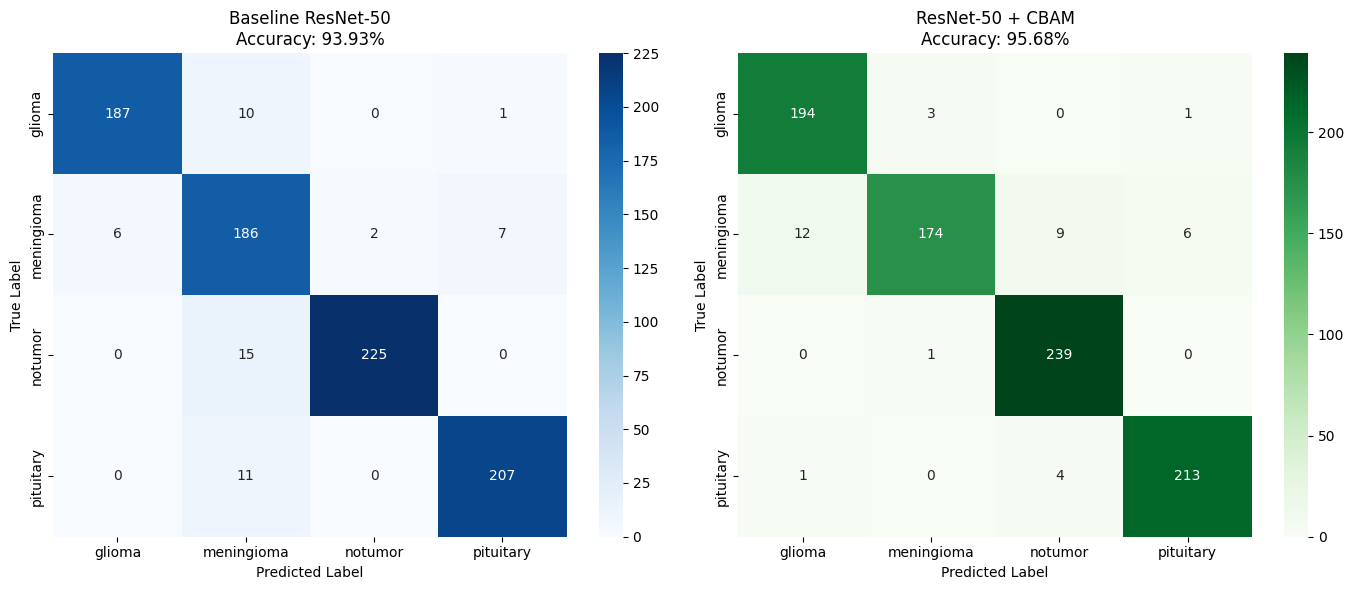


--- Per-Class F1 Score Comparison ---
Class           Baseline     CBAM         Diff        
--------------------------------------------------
glioma          0.9565       0.9580       +0.0015
meningioma      0.8794       0.9182       +0.0388
notumor         0.9636       0.9715       +0.0079
pituitary       0.9561       0.9726       +0.0165

MEAN            0.9389       0.9551       +0.0162


In [16]:
# --- EVALUATE BOTH MODELS ON TEST SET ---
# Evaluate baseline and CBAM models on the test set and produce reports/plots.
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

criterion_eval = nn.CrossEntropyLoss(weight=class_weights.to(device))

# NOTE: The checkpoint loading below expects a dict with key 'model_state_dict'
# or a raw state_dict. If the checkpoint file is missing or has a different format
# this will raise an exception. Consider wrapping with a safe loader if needed.

# Evaluate Baseline
print("\n--- Baseline ResNet-50 ---")
checkpoint = torch.load('best_baseline_model.pth', weights_only=False)
baseline_model.load_state_dict(checkpoint['model_state_dict'])
baseline_model.eval()

_, baseline_test_acc, baseline_f1, baseline_preds, baseline_labels = validate_epoch(
    baseline_model, test_loader, criterion_eval, device
)
print(f"Test Accuracy: {baseline_test_acc:.2f}%")
print(f"Mean F1: {baseline_f1.mean():.4f}")

# Evaluate CBAM
print("\n--- ResNet-50 + CBAM ---")
checkpoint = torch.load('best_cbam_model.pth', weights_only=False)
cbam_model.load_state_dict(checkpoint['model_state_dict'])
cbam_model.eval()

_, cbam_test_acc, cbam_f1, cbam_preds, cbam_labels = validate_epoch(
    cbam_model, test_loader, criterion_eval, device
)
print(f"Test Accuracy: {cbam_test_acc:.2f}%")
print(f"Mean F1: {cbam_f1.mean():.4f}")

# Comparison Table
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"\n{'Model':<25} {'Accuracy':<12} {'Mean F1':<12} {'Improvement':<12}")
print("-"*60)
print(f"{'Baseline ResNet-50':<25} {baseline_test_acc:<12.2f} {baseline_f1.mean():<12.4f} {'---':<12}")
print(f"{'ResNet-50 + CBAM':<25} {cbam_test_acc:<12.2f} {cbam_f1.mean():<12.4f} {cbam_test_acc - baseline_test_acc:+.2f}%")

# Classification Reports
print("\n--- Classification Reports ---")
print("\nBaseline ResNet-50:")
print(classification_report(baseline_labels, baseline_preds, target_names=class_names))
print("\nResNet-50 + CBAM:")
print(classification_report(cbam_labels, cbam_preds, target_names=class_names))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Baseline confusion matrix
cm_baseline = confusion_matrix(baseline_labels, baseline_preds)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Baseline ResNet-50\nAccuracy: {baseline_test_acc:.2f}%')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# CBAM confusion matrix
cm_cbam = confusion_matrix(cbam_labels, cbam_preds)
sns.heatmap(cm_cbam, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title(f'ResNet-50 + CBAM\nAccuracy: {cbam_test_acc:.2f}%')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class comparison
print("\n--- Per-Class F1 Score Comparison ---")
print(f"{'Class':<15} {'Baseline':<12} {'CBAM':<12} {'Diff':<12}")
print("-"*50)
for i, cls in enumerate(class_names):
    diff = cbam_f1[i] - baseline_f1[i]
    print(f"{cls:<15} {baseline_f1[i]:<12.4f} {cbam_f1[i]:<12.4f} {diff:+.4f}")

print(f"\n{'MEAN':<15} {baseline_f1.mean():<12.4f} {cbam_f1.mean():<12.4f} {cbam_f1.mean() - baseline_f1.mean():+.4f}")

## Part 8: Attention Visualization

In [17]:
# --- ATTENTION VISUALIZATION ---
# Utilities to denormalize input tensors and visualize spatial attention maps

def denormalize_image(tensor):
    # Undo ImageNet normalization so we can display the image correctly
    img = tensor.clone()
    for t, m, s in zip(img, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).cpu().numpy()


def visualize_attention_maps(model, image, true_label, class_names, device):
    # Run model forward pass and extract attention maps stored by CBAM
    model.eval()

    with torch.no_grad():
        input_tensor = image.unsqueeze(0).to(device)
        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()
        confidence = F.softmax(output, dim=1).max().item()

    # Attention maps are stored as tensors; convert to numpy for plotting.
    # IMPORTANT: some attention maps may be float arrays outside [0,255] —
    # PIL.Image.fromarray expects uint8 arrays; if you need to use PIL resizing,
    # convert/scale to uint8 first. Here we use numpy-based resize via PIL indirectly,
    # but ensure normalization before calling Image.fromarray in other contexts.
    attention_maps = model.get_attention_maps()
    orig_img = denormalize_image(image)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Original image
    axes[0, 0].imshow(orig_img)
    correct_str = "✓" if pred_class == true_label else "✗"
    axes[0, 0].set_title(f"Original MRI\nTrue: {class_names[true_label]}\nPred: {class_names[pred_class]} ({confidence:.1%}) {correct_str}")
    axes[0, 0].axis('off')

    # Attention maps overlayed on original image
    layer_names = ['layer1', 'layer2', 'layer3', 'layer4']
    positions = [(0, 1), (0, 2), (1, 0), (1, 1)]

    for layer_name, (row, col) in zip(layer_names, positions):
        att_map = attention_maps[layer_name][0, 0].cpu().numpy()
        # Normalize attention to [0,1] before resizing/overlay
        att_map_resized = np.array(Image.fromarray(att_map).resize((224, 224), Image.BILINEAR))
        att_map_resized = (att_map_resized - att_map_resized.min()) / (att_map_resized.max() - att_map_resized.min() + 1e-8)

        axes[row, col].imshow(orig_img)
        axes[row, col].imshow(att_map_resized, cmap='jet', alpha=0.5)
        axes[row, col].set_title(f"Attention: {layer_name}")
        axes[row, col].axis('off')

    # Combined attention (weighted sum of layers)
    combined_att = np.zeros((224, 224))
    weights = [0.1, 0.2, 0.3, 0.4]

    for layer_name, weight in zip(layer_names, weights):
        att_map = attention_maps[layer_name][0, 0].cpu().numpy()
        att_map_resized = np.array(Image.fromarray(att_map).resize((224, 224), Image.BILINEAR))
        att_map_resized = (att_map_resized - att_map_resized.min()) / (att_map_resized.max() - att_map_resized.min() + 1e-8)
        combined_att += weight * att_map_resized

    combined_att = (combined_att - combined_att.min()) / (combined_att.max() - combined_att.min() + 1e-8)

    axes[1, 2].imshow(orig_img)
    axes[1, 2].imshow(combined_att, cmap='jet', alpha=0.5)
    axes[1, 2].set_title("Combined Attention")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig(f'attention_{class_names[true_label]}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Attention visualization function defined.")

Attention visualization function defined.



Visualizing attention maps for each tumor type...

--- GLIOMA ---


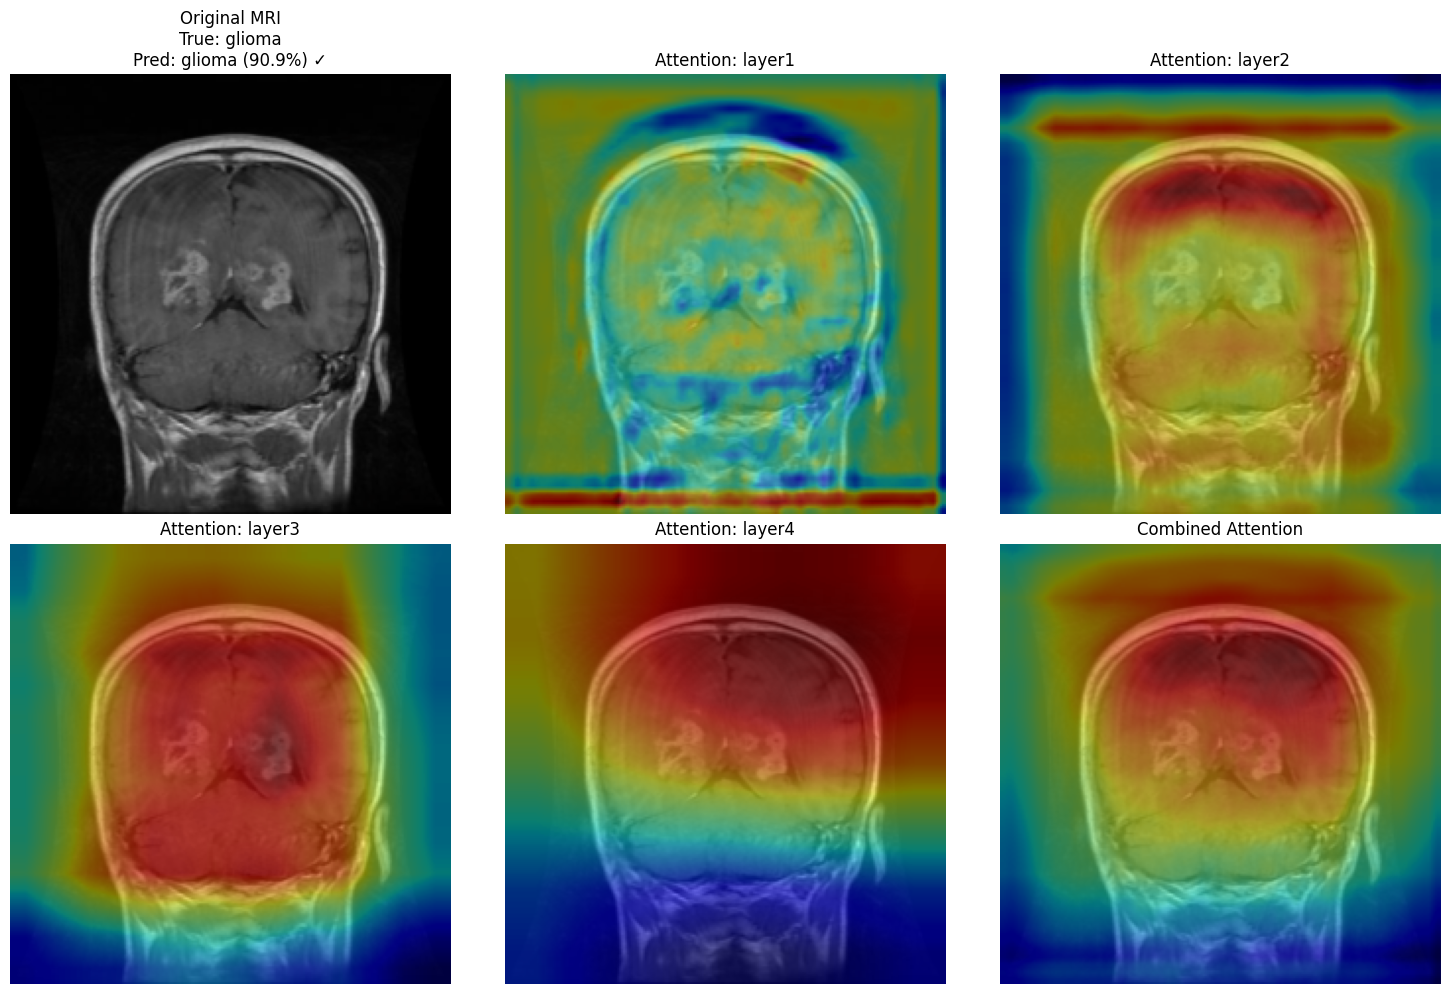


--- MENINGIOMA ---


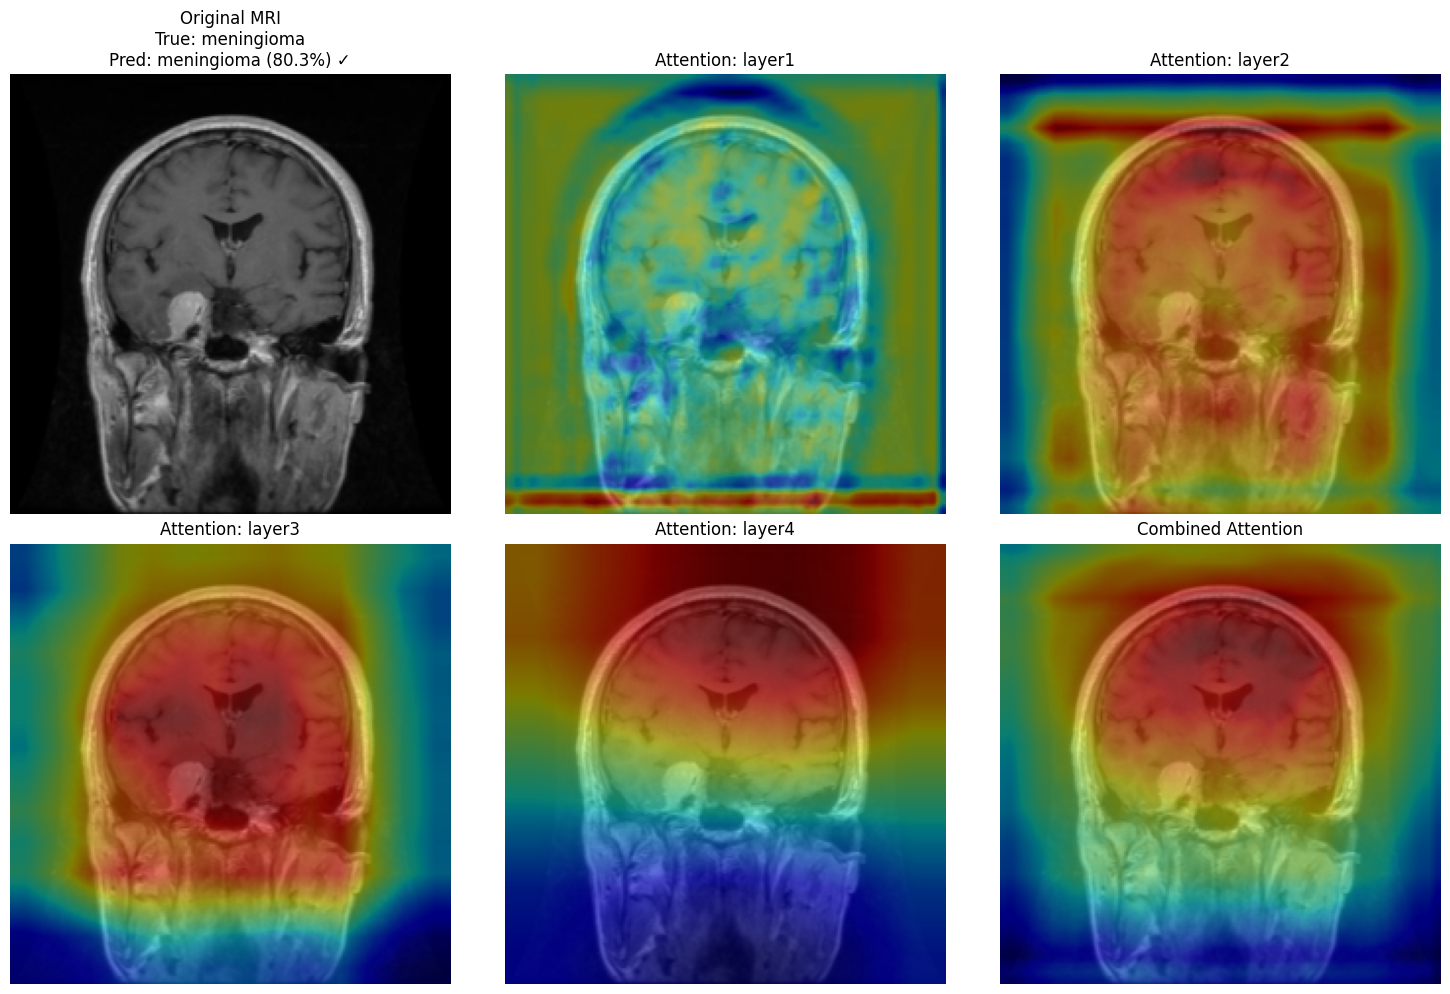


--- NOTUMOR ---


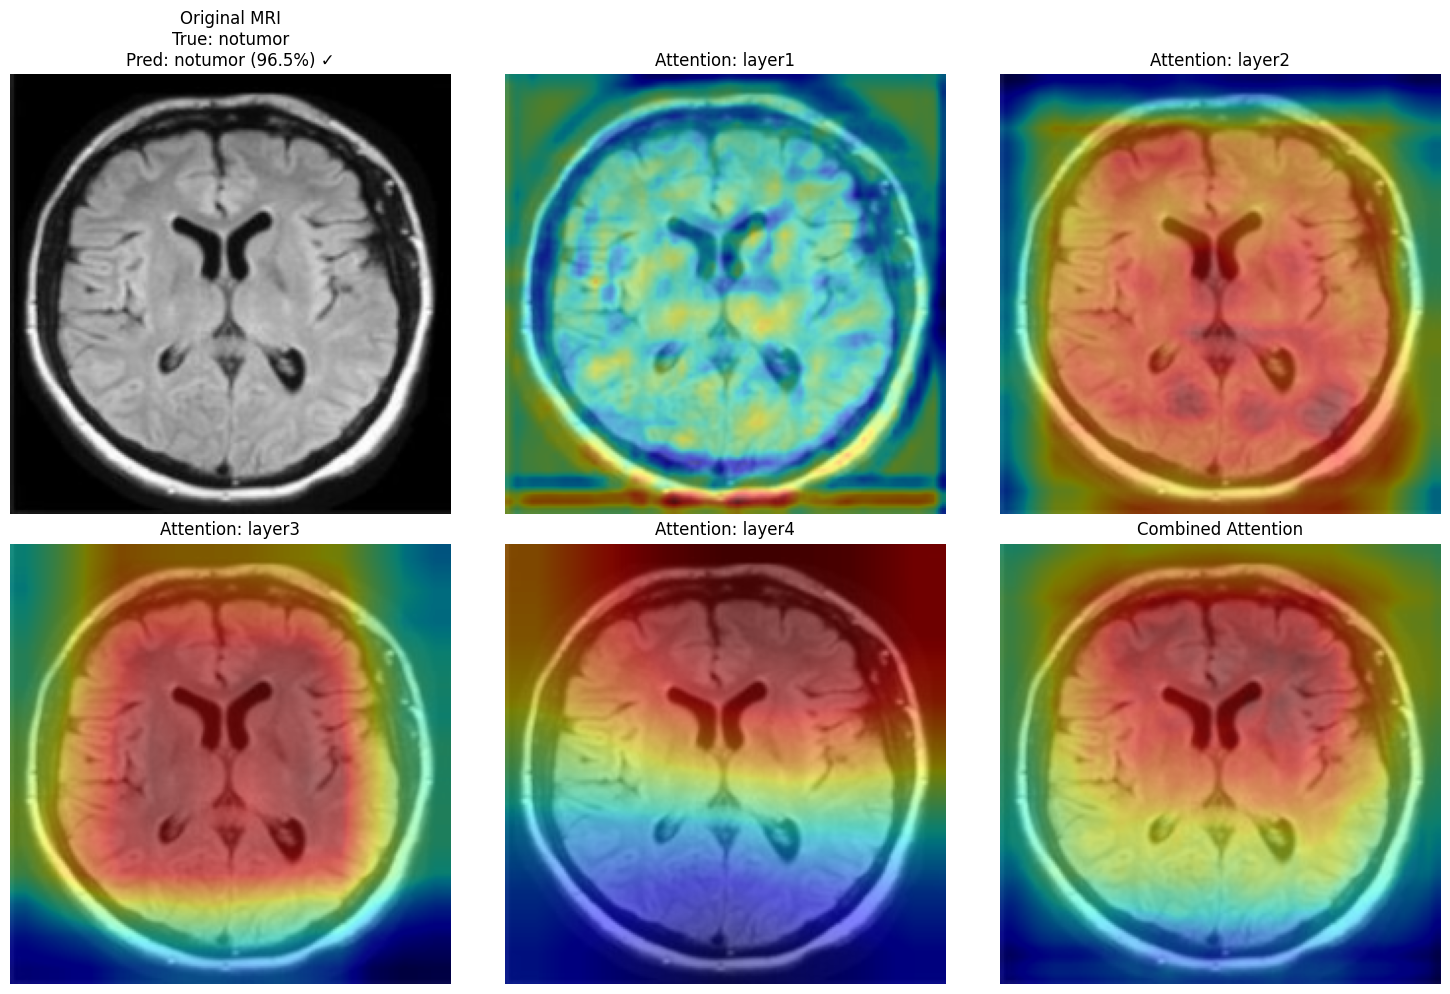


--- PITUITARY ---


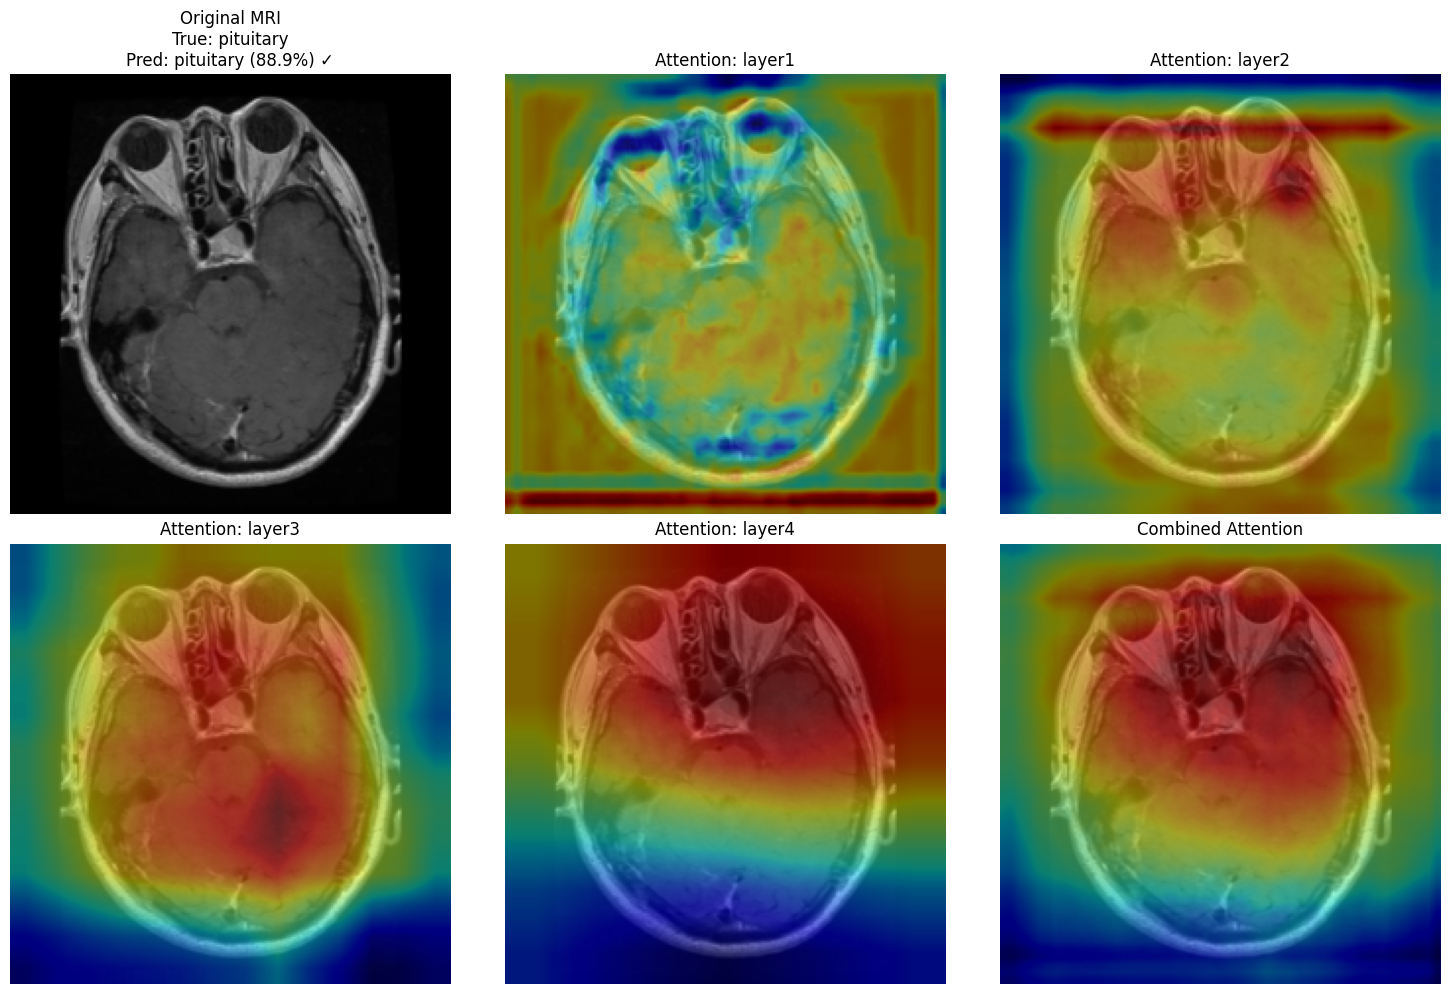

In [18]:
# --- VISUALIZE ATTENTION FOR EACH CLASS ---

print("\nVisualizing attention maps for each tumor type...")

samples_per_class = {}
for idx in range(len(test_dataset)):
    image, label = test_dataset[idx]
    if label not in samples_per_class:
        samples_per_class[label] = (image, label)
    if len(samples_per_class) == len(class_names):
        break

for label, (image, true_label) in sorted(samples_per_class.items()):
    print(f"\n--- {class_names[label].upper()} ---")
    visualize_attention_maps(cbam_model, image, true_label, class_names, device)

## Part 9: Attention Entropy Analysis


Analyzing attention entropy...


Analyzing attention entropy:  22%|██▏       | 6/27 [00:02<00:09,  2.12it/s]


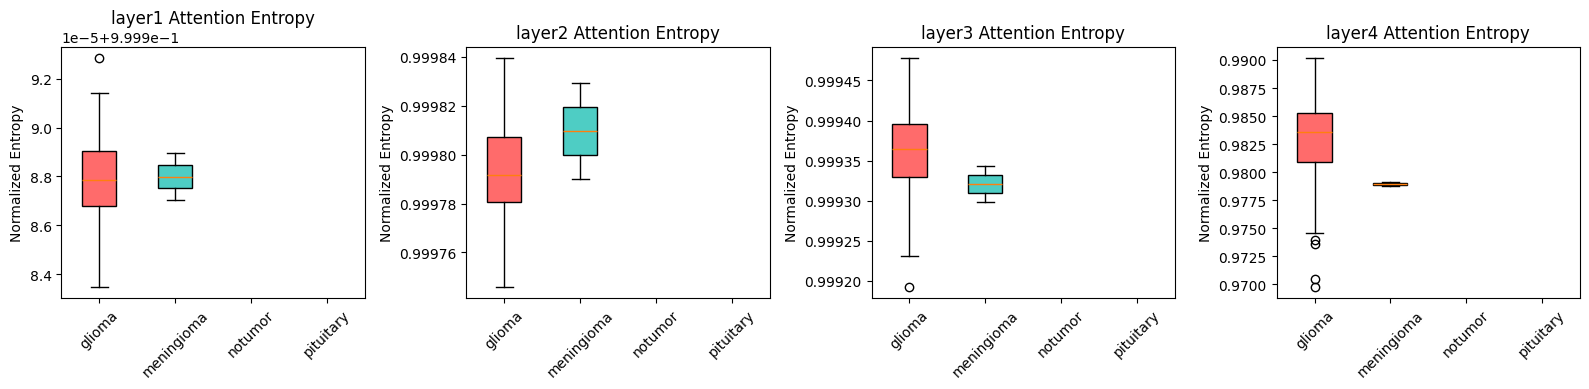


--- Attention Entropy Summary ---
Class           Layer1       Layer2       Layer3       Layer4      
---------------------------------------------------------------
glioma          1.0000       0.9998       0.9994       0.9830      
meningioma      1.0000       0.9998       0.9993       0.9789      
notumor         nan          nan          nan          nan         
pituitary       nan          nan          nan          nan         


In [19]:
# --- ATTENTION ENTROPY ANALYSIS ---

def calculate_attention_entropy(attention_map):
    """Calculate normalized entropy of attention map."""
    att_flat = attention_map.flatten()
    att_prob = att_flat / (att_flat.sum() + 1e-10)
    entropy = -np.sum(att_prob * np.log(att_prob + 1e-10))
    max_entropy = np.log(len(att_flat))
    return entropy / max_entropy


def analyze_attention_entropy(model, dataloader, class_names, device, max_samples=200):
    model.eval()

    entropy_by_class = {cls: {'layer1': [], 'layer2': [], 'layer3': [], 'layer4': []}
                        for cls in class_names}

    sample_count = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Analyzing attention entropy"):
            for i in range(len(images)):
                if sample_count >= max_samples:
                    break

                image = images[i:i+1].to(device)
                label = labels[i].item()

                _ = model(image)
                attention_maps = model.get_attention_maps()

                for layer_name in ['layer1', 'layer2', 'layer3', 'layer4']:
                    att_map = attention_maps[layer_name][0, 0].cpu().numpy()
                    entropy = calculate_attention_entropy(att_map)
                    entropy_by_class[class_names[label]][layer_name].append(entropy)

                sample_count += 1

            if sample_count >= max_samples:
                break

    return entropy_by_class


# Run entropy analysis
print("\nAnalyzing attention entropy...")
entropy_results = analyze_attention_entropy(cbam_model, test_loader, class_names, device)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
layers = ['layer1', 'layer2', 'layer3', 'layer4']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for idx, layer in enumerate(layers):
    data = [entropy_results[cls][layer] for cls in class_names]
    bp = axes[idx].boxplot(data, labels=class_names, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes[idx].set_title(f'{layer} Attention Entropy')
    axes[idx].set_ylabel('Normalized Entropy')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('attention_entropy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n--- Attention Entropy Summary ---")
print(f"{'Class':<15} {'Layer1':<12} {'Layer2':<12} {'Layer3':<12} {'Layer4':<12}")
print("-" * 63)
for cls in class_names:
    means = [np.mean(entropy_results[cls][layer]) for layer in layers]
    print(f"{cls:<15} {means[0]:<12.4f} {means[1]:<12.4f} {means[2]:<12.4f} {means[3]:<12.4f}")

## Part 10: Ensemble Training for Uncertainty

In [20]:
# --- ENSEMBLE TRAINING ---

def train_ensemble_cbam(num_models=3, stage1_epochs=3, stage2_epochs=10, seeds=[42, 123, 456]):
    """Train ensemble of CBAM models with two-stage training."""

    os.makedirs('ensemble_models', exist_ok=True)
    ensemble_models = []

    for idx, seed in enumerate(seeds[:num_models]):
        print(f"\n{'='*60}")
        print(f"Training Ensemble Model {idx+1}/{num_models} (Seed: {seed})")
        print(f"{'='*60}")

        torch.manual_seed(seed)
        np.random.seed(seed)

        model = ResNet50_CBAM(num_classes=len(class_names), pretrained=True)
        model = initialize_cbam_weights(model)
        model = model.to(device)

        criterion = LabelSmoothingLoss(len(class_names), smoothing=0.1, weight=class_weights.to(device))
        best_acc = 0.0

        # Stage 1: CBAM only
        print("\nStage 1: Training CBAM only...")
        for name, param in model.named_parameters():
            if 'cbam' not in name and 'fc' not in name:
                param.requires_grad = False

        opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

        for epoch in range(stage1_epochs):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, opt1, device)
            val_loss, val_acc, f1, _, _ = validate_epoch(model, val_loader, criterion, device)
            print(f"  S1 Epoch {epoch+1}: Train={train_acc:.1f}% Val={val_acc:.1f}%")
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), f'ensemble_models/model_{idx+1}_best.pth')

        # Stage 2: All layers
        print("\nStage 2: Fine-tuning all layers...")
        for param in model.parameters():
            param.requires_grad = True

        opt2 = get_optimizer_with_differential_lr(model, base_lr=0.00005, cbam_lr=0.0005)

        for epoch in range(stage2_epochs):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, opt2, device)
            val_loss, val_acc, f1, _, _ = validate_epoch(model, val_loader, criterion, device)
            print(f"  S2 Epoch {epoch+1}: Train={train_acc:.1f}% Val={val_acc:.1f}% F1={f1.mean():.3f}")
            if val_acc > best_acc:
                best_acc = val_acc
                torch.save(model.state_dict(), f'ensemble_models/model_{idx+1}_best.pth')

        model.load_state_dict(torch.load(f'ensemble_models/model_{idx+1}_best.pth'))
        ensemble_models.append(model)
        print(f"Model {idx+1} best accuracy: {best_acc:.2f}%")

    return ensemble_models

# Train ensemble
ensemble_models = train_ensemble_cbam(num_models=3, stage1_epochs=3, stage2_epochs=10)


Training Ensemble Model 1/3 (Seed: 42)
CBAM weights initialized for stable training

Stage 1: Training CBAM only...


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.65it/s, loss=0.6135, acc=90.32%]


  S1 Epoch 1: Train=77.6% Val=90.3%


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.19it/s, loss=0.7529, acc=89.15%]


  S1 Epoch 2: Train=87.9% Val=89.1%


...

  S2 Epoch 8: Train=98.9% Val=95.6% F1=0.953


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.50it/s, loss=0.4275, acc=98.72%]


  S2 Epoch 9: Train=99.1% Val=98.7% F1=0.987


Validating: 100%|██████████| 27/27 [00:03<00:00,  7.53it/s, loss=0.4891, acc=97.90%]


  S2 Epoch 10: Train=99.1% Val=97.9% F1=0.979
Model 3 best accuracy: 98.72%


## Part 11: Cross-Model Attention Consistency


Analyzing cross-model attention consistency...


Analyzing consistency:  11%|█         | 3/27 [00:03<00:27,  1.15s/it]


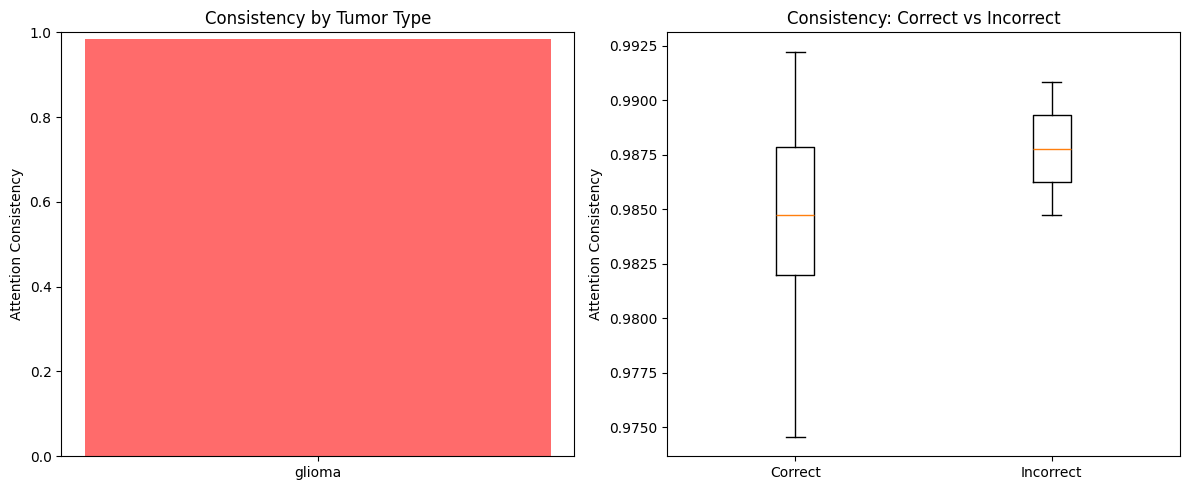


Correct predictions: 0.9845 ± 0.0042
Incorrect predictions: 0.9878 ± 0.0031


In [21]:
# --- ATTENTION CONSISTENCY ANALYSIS ---

def analyze_attention_consistency(models, dataloader, class_names, device, max_samples=100):
    """Analyze attention consistency across ensemble models."""

    consistency_by_class = {cls: [] for cls in class_names}
    consistency_correct = []
    consistency_incorrect = []

    sample_count = 0

    for images, labels in tqdm(dataloader, desc="Analyzing consistency"):
        for i in range(len(images)):
            if sample_count >= max_samples:
                break

            image = images[i]
            true_label = labels[i].item()
            input_tensor = image.unsqueeze(0).to(device)

            # Get predictions and attention from all models
            all_preds = []
            all_attention = []

            for model in models:
                model.eval()
                with torch.no_grad():
                    out = model(input_tensor)
                    all_preds.append(out.argmax(dim=1).item())
                    att = model.get_attention_maps()['layer4'][0, 0].cpu().numpy()
                    att = (att - att.min()) / (att.max() - att.min() + 1e-8)
                    all_attention.append(att)

            # Majority vote
            pred_label = max(set(all_preds), key=all_preds.count)
            is_correct = (pred_label == true_label)

            # Calculate consistency (1 - mean pairwise MSE)
            total_mse = 0
            count = 0
            for j in range(len(all_attention)):
                for k in range(j+1, len(all_attention)):
                    total_mse += np.mean((all_attention[j] - all_attention[k])**2)
                    count += 1

            consistency = 1 - min(total_mse / count if count > 0 else 0, 1)

            consistency_by_class[class_names[true_label]].append(consistency)
            if is_correct:
                consistency_correct.append(consistency)
            else:
                consistency_incorrect.append(consistency)

            sample_count += 1

        if sample_count >= max_samples:
            break

    return consistency_by_class, consistency_correct, consistency_incorrect


# Run analysis
print("\nAnalyzing cross-model attention consistency...")
cons_by_class, cons_correct, cons_incorrect = analyze_attention_consistency(
    ensemble_models, test_loader, class_names, device, max_samples=100
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# By class
class_means = [np.mean(cons_by_class[cls]) for cls in class_names]
axes[0].bar(class_names, class_means, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[0].set_ylabel('Attention Consistency')
axes[0].set_title('Consistency by Tumor Type')
axes[0].set_ylim([0, 1])

# Correct vs Incorrect
axes[1].boxplot([cons_correct, cons_incorrect], labels=['Correct', 'Incorrect'])
axes[1].set_ylabel('Attention Consistency')
axes[1].set_title('Consistency: Correct vs Incorrect')

plt.tight_layout()
plt.savefig('attention_consistency.png', dpi=150)
plt.show()

print(f"\nCorrect predictions: {np.mean(cons_correct):.4f} ± {np.std(cons_correct):.4f}")
print(f"Incorrect predictions: {np.mean(cons_incorrect):.4f} ± {np.std(cons_incorrect):.4f}")

## Part 12: Temperature Scaling

In [22]:
# --- TEMPERATURE SCALING ---

class TemperatureScaling:
    def __init__(self):
        self.temperature = None

    def fit(self, models, dataloader, device):
        for model in models:
            model.eval()

        all_logits = []
        all_labels = []

        print("Collecting validation logits...")
        with torch.no_grad():
            for images, labels in tqdm(dataloader):
                images = images.to(device)
                ensemble_logits = [model(images) for model in models]
                mean_logits = torch.stack(ensemble_logits).mean(dim=0)
                all_logits.append(mean_logits.cpu())
                all_labels.append(labels)

        all_logits = torch.cat(all_logits).to(device)
        all_labels = torch.cat(all_labels).to(device)

        self.temperature = nn.Parameter(torch.ones(1, device=device))
        optimizer = optim.LBFGS([self.temperature], lr=0.01, max_iter=50)

        def closure():
            optimizer.zero_grad()
            loss = nn.CrossEntropyLoss()(all_logits / self.temperature, all_labels)
            loss.backward()
            return loss

        optimizer.step(closure)
        self.temperature.data.clamp_(0.1, 10.0)
        print(f"Learned temperature: {self.temperature.item():.4f}")

    def scale(self, logits):
        return logits / self.temperature

# Fit temperature scaling
print("\nFitting temperature scaling...")
temp_scaler = TemperatureScaling()
temp_scaler.fit(ensemble_models, val_loader, device)


Fitting temperature scaling...


100%|██████████| 27/27 [00:04<00:00,  6.12it/s]


Learned temperature: 0.7268


## Part 13: Full Uncertainty Estimation

In [23]:
# --- TEST-TIME AUGMENTATION ---

class TestTimeAugmentation:
    def __init__(self):
        self.augmentations = [
            transforms.Lambda(lambda x: x),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.RandomRotation(degrees=5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
        ]

    def generate_augmented_batch(self, image, num_augmentations=5):
        if isinstance(image, torch.Tensor):
            image_np = image.clone()
            for t, m, s in zip(image_np, IMAGENET_MEAN, IMAGENET_STD):
                t.mul_(s).add_(m)
            image_np = torch.clamp(image_np, 0, 1)
            image_pil = transforms.ToPILImage()(image_np.cpu())
        else:
            image_pil = image

        augmented = []
        for i in range(num_augmentations):
            aug_idx = i % len(self.augmentations)
            aug_transform = transforms.Compose([
                self.augmentations[aug_idx],
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
            ])
            augmented.append(aug_transform(image_pil))

        return augmented

In [24]:
# --- HYBRID UNCERTAINTY ESTIMATOR ---

class HybridUncertaintyEstimator:
    def __init__(self, ensemble_models, temperature_scaler, class_names, device):
        self.ensemble_models = ensemble_models
        self.temperature_scaler = temperature_scaler
        self.class_names = class_names
        self.device = device
        self.tta = TestTimeAugmentation()

        for model in self.ensemble_models:
            model.to(device)
            model.eval()

    def predict_with_uncertainty(self, image, num_tta=5, num_mc_samples=10):
        all_predictions = []

        augmented_images = self.tta.generate_augmented_batch(image, num_tta)

        for aug_image in augmented_images:
            aug_image = aug_image.unsqueeze(0).to(self.device)

            for model in self.ensemble_models:
                model.enable_dropout_inference()

                for _ in range(num_mc_samples):
                    with torch.no_grad():
                        logits = model(aug_image)
                        scaled_logits = self.temperature_scaler.scale(logits)
                        probs = F.softmax(scaled_logits, dim=1)
                        all_predictions.append(probs.cpu().numpy())

        all_predictions = np.array(all_predictions).squeeze()

        mean_prediction = np.mean(all_predictions, axis=0)
        total_uncertainty = np.mean(np.var(all_predictions, axis=0))

        mean_pred_safe = np.clip(mean_prediction, 1e-10, 1.0)
        predictive_entropy = -np.sum(mean_pred_safe * np.log(mean_pred_safe))

        predicted_class = np.argmax(mean_prediction)
        confidence = np.max(mean_prediction)

        return {
            'prediction': mean_prediction,
            'predicted_class': predicted_class,
            'predicted_label': self.class_names[predicted_class],
            'confidence': confidence,
            'total_uncertainty': total_uncertainty,
            'predictive_entropy': predictive_entropy,
        }

    def predict_batch(self, dataloader, num_tta=5, num_mc_samples=10, max_samples=None):
        all_results = []
        sample_count = 0

        for images, labels in tqdm(dataloader, desc="Processing"):
            for idx in range(len(images)):
                if max_samples and sample_count >= max_samples:
                    break

                result = self.predict_with_uncertainty(images[idx], num_tta, num_mc_samples)
                result['true_label'] = labels[idx].item()
                result['correct'] = (result['predicted_class'] == labels[idx].item())

                all_results.append(result)
                sample_count += 1

            if max_samples and sample_count >= max_samples:
                break

        return all_results

# Initialize estimator
print("\nInitializing Hybrid Uncertainty Estimator...")
estimator = HybridUncertaintyEstimator(ensemble_models, temp_scaler, class_names, device)

# Run evaluation
print("Running uncertainty estimation on test set...")
test_results = estimator.predict_batch(test_loader, num_tta=5, num_mc_samples=10)


Initializing Hybrid Uncertainty Estimator...
Running uncertainty estimation on test set...


Processing: 100%|██████████| 27/27 [19:03<00:00, 42.35s/it]


## Part 14: Final Metrics and Results

In [25]:
# --- CALCULATE COMPREHENSIVE METRICS ---

def calculate_metrics(results, class_names):
    predictions = np.array([r['predicted_class'] for r in results])
    true_labels = np.array([r['true_label'] for r in results])
    confidences = np.array([r['confidence'] for r in results])
    uncertainties = np.array([r['total_uncertainty'] for r in results])
    correct = np.array([r['correct'] for r in results])

    accuracy = np.mean(correct) * 100
    f1_scores = f1_score(true_labels, predictions, average=None)

    # ECE
    n_bins = 15
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            acc_in_bin = np.mean(correct[in_bin])
            conf_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(conf_in_bin - acc_in_bin) * prop_in_bin

    # Uncertainty-Error correlation
    unc_corr, _ = spearmanr(uncertainties, ~correct)

    # Selective prediction
    sorted_idx = np.argsort(uncertainties)
    coverage = np.linspace(0.5, 1.0, 11)
    sel_acc = [np.mean(correct[sorted_idx[:max(1, int(c*len(results)))]]) * 100 for c in coverage]

    return {
        'accuracy': accuracy,
        'f1_scores': f1_scores,
        'mean_f1': np.mean(f1_scores),
        'ece': ece,
        'unc_error_corr': unc_corr,
        'selective_prediction': {'coverage': coverage.tolist(), 'accuracy': sel_acc},
        'mean_confidence': np.mean(confidences),
        'mean_uncertainty': np.mean(uncertainties)
    }

# Calculate metrics
metrics = calculate_metrics(test_results, class_names)

print("\n" + "="*70)
print("FINAL RESULTS: CBAM + UNCERTAINTY QUANTIFICATION")
print("="*70)

print(f"\n--- Classification ---")
print(f"  Accuracy: {metrics['accuracy']:.2f}%")
print(f"  Mean F1: {metrics['mean_f1']:.4f}")
for cls, f1 in zip(class_names, metrics['f1_scores']):
    print(f"    {cls}: {f1:.4f}")

print(f"\n--- Calibration ---")
print(f"  ECE: {metrics['ece']:.4f} {'✓ PASS' if metrics['ece'] < 0.1 else '✗ FAIL'} (target < 0.1)")
print(f"  Uncertainty-Error Correlation: {metrics['unc_error_corr']:.4f}")

print(f"\n--- Comparison ---")
print(f"  Baseline: {baseline_test_acc:.2f}%")
print(f"  CBAM + UQ: {metrics['accuracy']:.2f}%")
print(f"  Improvement: {metrics['accuracy'] - baseline_test_acc:+.2f}%")


FINAL RESULTS: CBAM + UNCERTAINTY QUANTIFICATION

--- Classification ---
  Accuracy: 99.30%
  Mean F1: 0.9927
    glioma: 0.9924
    meningioma: 0.9851
    notumor: 0.9979
    pituitary: 0.9954

--- Calibration ---
  ECE: 0.0422 ✓ PASS (target < 0.1)
  Uncertainty-Error Correlation: 0.1078

--- Comparison ---
  Baseline: 93.93%
  CBAM + UQ: 99.30%
  Improvement: +5.37%


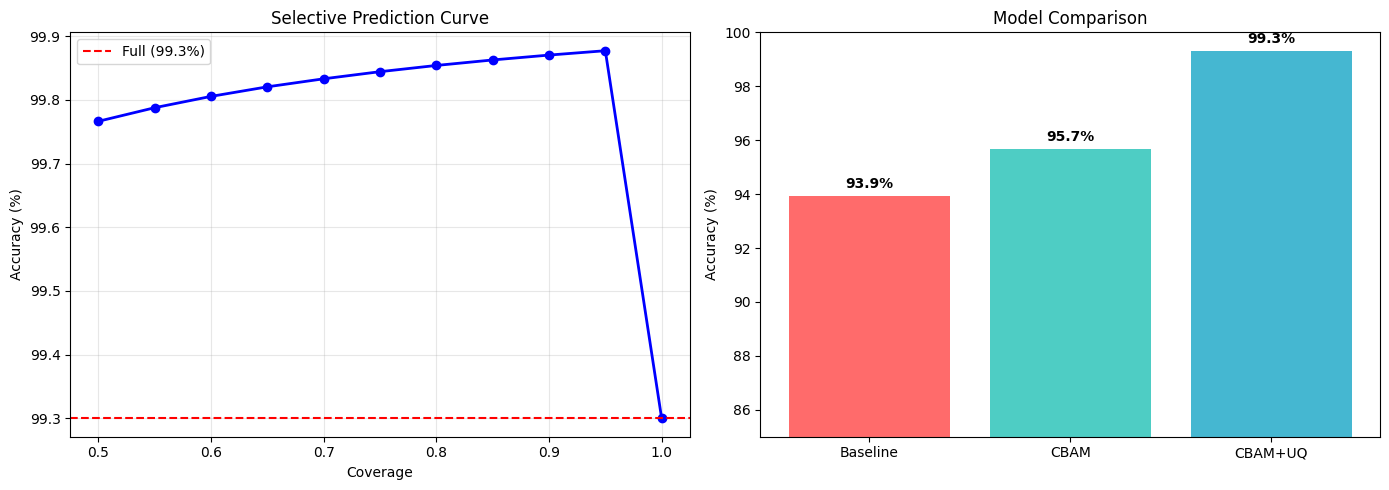

In [26]:
# --- VISUALIZATIONS ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Selective Prediction
axes[0].plot(metrics['selective_prediction']['coverage'],
             metrics['selective_prediction']['accuracy'], 'b-o', linewidth=2)
axes[0].axhline(y=metrics['accuracy'], color='r', linestyle='--', label=f'Full ({metrics["accuracy"]:.1f}%)')
axes[0].set_xlabel('Coverage')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Selective Prediction Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Model Comparison
models_list = ['Baseline', 'CBAM', 'CBAM+UQ']
accs = [baseline_test_acc, cbam_test_acc, metrics['accuracy']]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[1].bar(models_list, accs, color=colors)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model Comparison')
axes[1].set_ylim([85, 100])
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('final_results.png', dpi=150)
plt.show()

In [27]:
# --- SAVE ALL RESULTS ---
# Prepare a JSON-serializable results dictionary and save to disk.
# Note: metrics may contain numpy arrays; ensure they are converted to Python lists/floats.

def to_serializable(obj):
    # Convert containers and numpy arrays to native Python types so json.dump works.
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_serializable(i) for i in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64, np.int32, np.int64)):
        return obj.item()
    return obj

# Build results payload (use safe casts where necessary)
results_dict = {
    'baseline': {'accuracy': float(baseline_test_acc), 'f1': float(baseline_f1.mean())},
    'cbam': {'accuracy': float(cbam_test_acc), 'f1': float(cbam_f1.mean())},
    'cbam_uncertainty': to_serializable(metrics),
    'improvement': float(metrics['accuracy'] - baseline_test_acc),
    'config': {
        'num_ensemble': int(len(ensemble_models)) if 'ensemble_models' in globals() else 0,
        'temperature': float(temp_scaler.temperature.item()) if ('temp_scaler' in globals() and getattr(temp_scaler, 'temperature', None) is not None) else None,
        'class_names': list(class_names) if 'class_names' in globals() else []
    }
}

# Write results to a JSON file
with open('complete_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("\nResults saved to complete_results.json")


Results saved to complete_results.json


In [28]:
from google.colab import files
files.download('complete_results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
# --- FINAL SUMMARY ---

print("\n" + "="*70)
print("PROJECT COMPLETE: Trustworthy Brain Tumor Classification")
print("="*70)

print(f"\n✓ PERFORMANCE")
print("-"*40)
print(f"  Baseline: {baseline_test_acc:.2f}%")
print(f"  CBAM + UQ: {metrics['accuracy']:.2f}%")
print(f"  ECE: {metrics['ece']:.4f} (target < 0.1)")

print("\n" + "="*70)
print("="*70)


PROJECT COMPLETE: Trustworthy Brain Tumor Classification

✓ PERFORMANCE
----------------------------------------
  Baseline: 93.93%
  CBAM + UQ: 99.30%
  ECE: 0.0422 (target < 0.1)

